# **ReAct**
# Reasoning + Acting

In [1]:
from langchain_openai import ChatOpenAI
import os
import load_dotenv

# This function will load all the variables from the .env file and 
# make them available in the os.environ dictionary (env variables)
load_dotenv.load_dotenv() 

if os.environ.get("OPENAI_API_KEY"):
    print("API veriable exists")
else:
    raise ValueError("OPENAI_API_KEY not found")

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser

llm_openai = ChatOpenAI(model='gpt-5-mini', temperature=0)

API veriable exists


# **Tools**

In [9]:
# TOOL - 1 [New Search Tool]
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

# TOOL - 2 [Wikipedia Search Tool]
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(),
description="This a tool to search Wikipedia")

# TOOL - 3 [CUstome Enterprise Tool]

from langchain.tools import tool

@tool
def enterprise_tool(query:str)->str:
    """
        This a tool to send email to enterprise
    """
    return "Email Sent."




In [ ]:
ToolKit = [search_tool, wikipedia_tool, enterprise_tool]
ToolKit

In [8]:
wikipedia_tool.invoke("What is the apital of France?")

'Page: Fumio Kishida\nSummary: Fumio Kishida (born 29 July 1957) is a Japanese politician who served as Prime Minister of Japan and President of the Liberal Democratic Party (LDP) from 2021 until his resignation in 2024. He has represented Hiroshima 1st in the House of Representatives since 1996. Before his premiership, he was the Minister for Foreign Affairs from 2012 to 2017, as acting Minister of Defense in 2017, and he also chaired the LDP Policy Research Council from 2017 to 2020.\nBorn into a political family, Kishida spent part of his childhood in the United States, where he attended elementary school in New York City. After beginning his career in finance, Kishida entered politics and was elected to the House of Representatives at the 1993 general election as a member of the LDP. Kishida was appointed to Minister of State for Special Missions in the premiership of Shinzo Abe and Yasuo Fukuda from 2007 to 2008, and was appointed Minister for Foreign Affairs in 2012 after Abe reg

# **ReAct Agent**

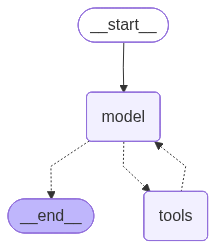

In [12]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-5-mini",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
   
)
agent = create_agent(model, tools=ToolKit)
agent

# **ReAct Agent Invok with Streams**

In [15]:
example_query = "Give the latest news about the stock market?"

events = agent.stream(
    {"messages":[('user', example_query)]},
    stream_mode="values"
)

for event in events:
    print(event)

{'messages': [HumanMessage(content='Give the latest news about the stock market?', additional_kwargs={}, response_metadata={}, id='c484799f-376b-474b-968e-4219759560c9')]}
{'messages': [HumanMessage(content='Give the latest news about the stock market?', additional_kwargs={}, response_metadata={}, id='c484799f-376b-474b-968e-4219759560c9'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 170, 'prompt_tokens': 214, 'total_tokens': 384, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DP93GRX0rRvOert0P7DP6alDgLhIQ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d3f68-afa3-7720-8619-1f9ea03622f8-0', tool_calls=[{

# **Manually Binding The LLM With Tools**

In [16]:
# Without Binding
llm_openai.invoke("What's the lates news about the stock market?")

AIMessage(content='I don’t have live internet access, so I can’t pull up real‑time headlines. My training goes to mid‑2024, so I may miss anything that happened since then.\n\nI can help in two ways — pick one:\n- I can tell you how to get the latest market news quickly and what to look for (fast guide + sources and search queries).  \n- Or you can tell me which market/index/stock(s) or region you care about and I’ll tell you what types of news typically move them and what to watch for; if you paste a headline or link I can summarize or analyze it.\n\nQuick guide to get the latest stock‑market news right now\n- Real‑time sites/apps: Bloomberg, Reuters, CNBC, Financial Times, Wall Street Journal, MarketWatch. For free quick quotes use Google Finance, Yahoo Finance, or your broker’s app.  \n- Key indices to check: S&P 500, Dow Jones Industrial Average, Nasdaq Composite (U.S.); FTSE 100 (U.K.); DAX (Germany); Nikkei 225 (Japan).  \n- Fast data points: intraday % change for major indices, 

In [17]:
# With Binding
llm_bind = llm_openai.bind_tools(ToolKit)
llm_bind.invoke("What's the lates news about the stock market?")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 215, 'total_tokens': 373, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DP9B41CTASeLhpECAvI9ewn0bGHl6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d3f70-cb47-7c43-ac1f-79d13ca7f793-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest stock market news today'}, 'id': 'call_fCOSObUE7PpIW3SPssbi3nzW', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 215, 'output_tokens': 158, 'total_tokens': 373, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reas